In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser('~/aispp-sims/gaussian-wavefront-spatially-resolved-inference/helpers/'))

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import ImageShotDataset


DATA_DIR = os.path.expanduser(
    '~/aispp-sims/gaussian-wavefront-spatially-resolved-inference/data/'
    'R40_N200_A1000000_muXStd10.0um_muVxStd10.0um_sigX100um_sigVx100um_'
    'sigXStd10.0um_sigVxStd10.0um_phi0random_sig_A0.100_f0.3000'
)
RUN = 'run_039'

In [2]:
Z0   = ImageShotDataset(os.path.join(DATA_DIR, RUN, 'Z0',   'data_IMG.h5'))
Z100 = ImageShotDataset(os.path.join(DATA_DIR, RUN, 'Z100', 'data_IMG.h5'))

with h5py.File(Z0.path) as f:
    signal_amp   = float(f.attrs['signal_amp'])
    signal_freq  = float(f.attrs['signal_freq'])
    signal_phase = float(f.attrs['signal_phase'])

print(f'{Z0.n_shots} shots,  {Z0.n_atoms_launched:,} atoms launched/shot')
print(f'Image: {Z0.res}×{Z0.res}  window ±{Z0.half_range*1e3:.0f}mm  pixel={Z0.pixel_size*1e6:.1f}µm')
print(f'phi0 range: [{Z0.phi0.min():.2f}, {Z0.phi0.max():.2f}] rad')
print(f'signal: amp={signal_amp:.3f} rad  freq={signal_freq:.4f} cyc/shot  phase={signal_phase:.3f} rad')
print(f'Detection efficiency — Z0: {Z0.detection_efficiency():.3f}  Z100: {Z100.detection_efficiency():.3f}')

200 shots,  1,000,000 atoms launched/shot
Image: 2048×2048  window ±3mm  pixel=2.9µm
phi0 range: [0.09, 6.26] rad
signal: amp=0.100 rad  freq=0.3000 cyc/shot  phase=0.500 rad
Detection efficiency — Z0: 0.909  Z100: 0.763


Shot 5: 900,853 ground  |  1,146 excited  |  total 901,999
phi0 = 3.363 rad


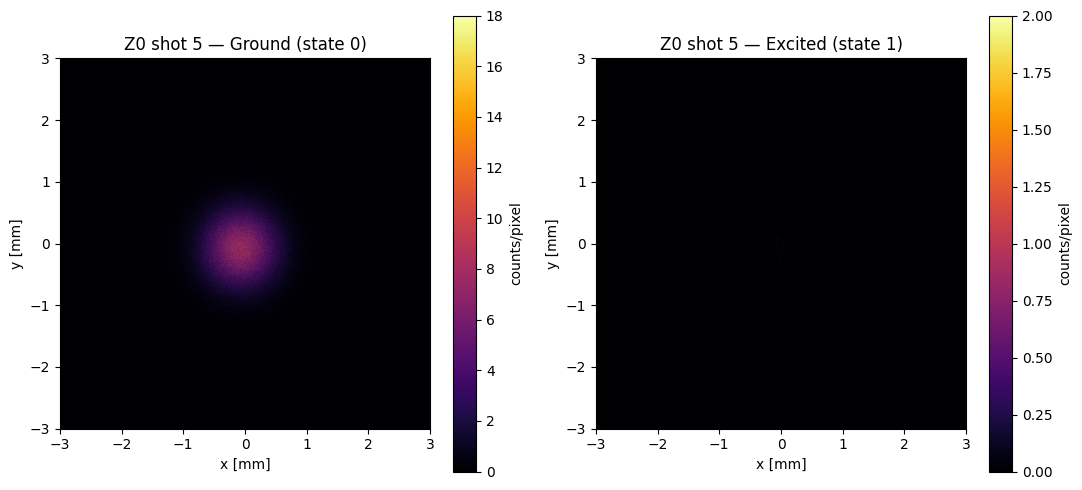

In [3]:
idx = 5
img = Z0[idx]   # shape (2, 2048, 2048)  —  img[0]=state0, img[1]=state1
lim = Z0.half_range * 1e3   # mm

n_s0 = int(img[0].sum())
n_s1 = int(img[1].sum())
print(f'Shot {idx}: {n_s0:,} ground  |  {n_s1:,} excited  |  total {n_s0+n_s1:,}')
print(f'phi0 = {Z0.phi0[idx]:.3f} rad')

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
extent = [-lim, lim, -lim, lim]

for ax, state_img, label in zip(axes, img, ['Ground (state 0)', 'Excited (state 1)']):
    im = ax.imshow(state_img.T, origin='lower', extent=extent,
                   #norm=plt.matplotlib.colors.LogNorm(vmin=0.5),
                   cmap='inferno', aspect='equal')
    plt.colorbar(im, ax=ax, label='counts/pixel')
    ax.set_title(f'Z0 shot {idx} — {label}')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')

plt.tight_layout()
plt.show()

/tmp/ipykernel_864986/649463508.py:9: RuntimeWarning: invalid value encountered in divide
  frac_z0   = np.where(total_z0   > 0, img_z0[0]   / total_z0,   np.nan)
/tmp/ipykernel_864986/649463508.py:10: RuntimeWarning: invalid value encountered in divide
  frac_z100 = np.where(total_z100 > 0, img_z100[0] / total_z100, np.nan)


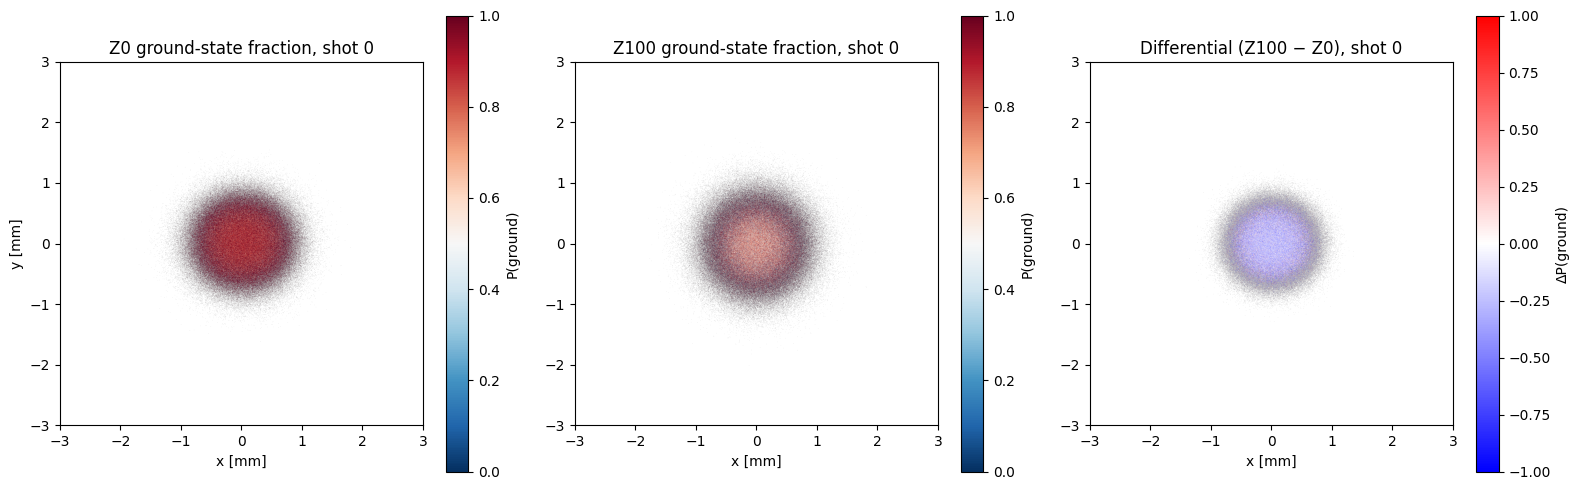

In [4]:
idx = 0
img_z0   = Z0[idx]    # (2, res, res)
img_z100 = Z100[idx]

# Total counts per pixel (s0 + s1) and local ground-state fraction
total_z0   = img_z0[0].astype(float)   + img_z0[1].astype(float)
total_z100 = img_z100[0].astype(float) + img_z100[1].astype(float)

frac_z0   = np.where(total_z0   > 0, img_z0[0]   / total_z0,   np.nan)
frac_z100 = np.where(total_z100 > 0, img_z100[0] / total_z100, np.nan)
diff_frac  = frac_z100 - frac_z0   # differential ground-state fraction

extent = [-lim, lim, -lim, lim]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(frac_z0.T, origin='lower', extent=extent,
                     vmin=0, vmax=1, cmap='RdBu_r', aspect='equal')
plt.colorbar(im0, ax=axes[0], label='P(ground)')
axes[0].set_title(f'Z0 ground-state fraction, shot {idx}')
axes[0].set_xlabel('x [mm]'); axes[0].set_ylabel('y [mm]')

im1 = axes[1].imshow(frac_z100.T, origin='lower', extent=extent,
                     vmin=0, vmax=1, cmap='RdBu_r', aspect='equal')
plt.colorbar(im1, ax=axes[1], label='P(ground)')
axes[1].set_title(f'Z100 ground-state fraction, shot {idx}')
axes[1].set_xlabel('x [mm]')

vmax = np.nanpercentile(np.abs(diff_frac), 99)
im2 = axes[2].imshow(diff_frac.T, origin='lower', extent=extent,
                     vmin=-vmax, vmax=vmax, cmap='bwr', aspect='equal')
plt.colorbar(im2, ax=axes[2], label='ΔP(ground)')
axes[2].set_title(f'Differential (Z100 − Z0), shot {idx}')
axes[2].set_xlabel('x [mm]')

plt.tight_layout()
plt.show()

/tmp/ipykernel_864986/2508221483.py:2: RuntimeWarning: invalid value encountered in divide
  fringe_z0 = (img_z0[0])/(img_z0[0] + img_z0[1])
/tmp/ipykernel_864986/2508221483.py:3: RuntimeWarning: invalid value encountered in divide
  fringe_z100 = (img_z100[0])/(img_z100[0] + img_z100[1])


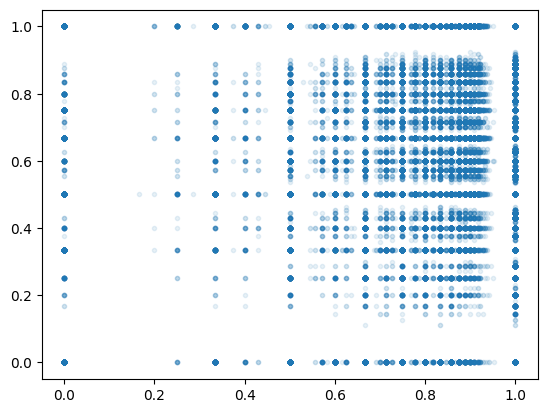

In [ ]:
# plot the one image ellipse
# rebin the images to reduce the number of points in the scatter plot
def rebin_image(img, factor):
    """Rebin a 2D image by averaging over non-overlapping blocks of size factor×factor."""
    shape = (img.shape[0]//factor, factor, img.shape[1]//factor, factor)
    return img.reshape(shape).mean(-1).mean(1)

img_z0_rebinned   = rebin_image(img_z0,   factor=8)
img_z100_rebinned = rebin_image(img_z100, factor=8)

fringe_z0 = (img_z0_rebinned[0])/(img_z0_rebinned[0] + img_z0_rebinned[1])
fringe_z100 = (img_z100_rebinned[0])/(img_z100_rebinned[0] + img_z100_rebinned[1])

plt.plot(fringe_z0.flatten(), fringe_z100.flatten(), '.', alpha=0.1)

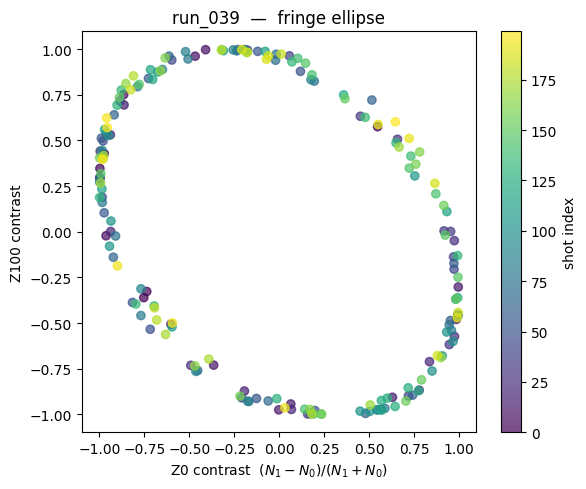

In [5]:
n_z0   = Z0.state_counts()    # DataFrame columns {0: ground, 1: excited}
n_z100 = Z100.state_counts()

nground_z0   = n_z0[0]
nexcited_z0  = n_z0[1]
nground_z100 = n_z100[0]
nexcited_z100 = n_z100[1]

diff0   = (nexcited_z0   - nground_z0)   / (nexcited_z0   + nground_z0)
diff100 = (nexcited_z100 - nground_z100) / (nexcited_z100 + nground_z100)

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(diff0, diff100, alpha=0.7, c=np.arange(len(diff0)), cmap='viridis')
plt.colorbar(sc, ax=ax, label='shot index')
ax.set_xlabel('Z0 contrast  $(N_1 - N_0)/(N_1 + N_0)$')
ax.set_ylabel('Z100 contrast')
ax.set_title(f'{RUN}  —  fringe ellipse')
plt.tight_layout()
plt.show()

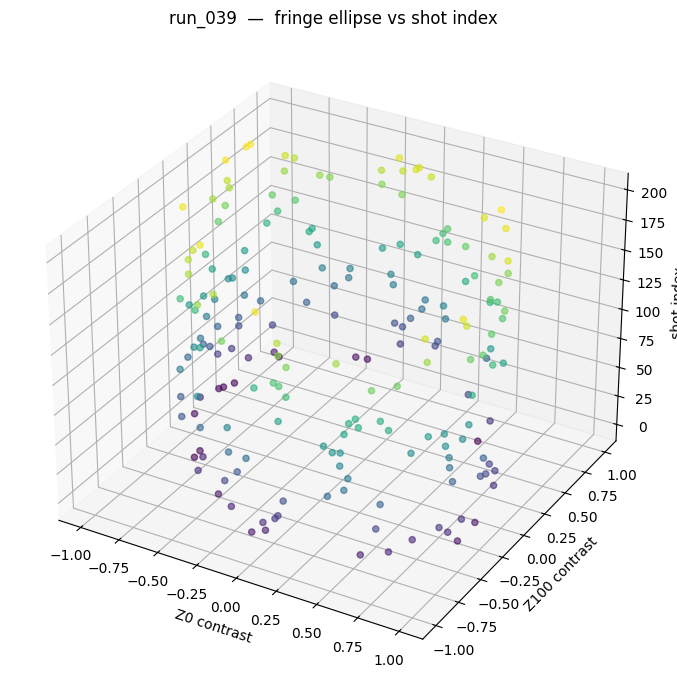

In [6]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(diff0, diff100, np.arange(len(diff0)),
           alpha=0.6, c=np.arange(len(diff0)), cmap='viridis')
ax.set_xlabel('Z0 contrast')
ax.set_ylabel('Z100 contrast')
ax.set_zlabel('shot index')
ax.set_title(f'{RUN}  —  fringe ellipse vs shot index')
plt.tight_layout()
plt.show()

In [7]:
USE_CUPY = True

try:
    import cupy as cp
    from cupyx.scipy.special import gammaln, logsumexp
    _cupy_available = True
except Exception:
    cp = None
    _cupy_available = False

xp = cp if USE_CUPY and _cupy_available else np
if xp is np:
    from scipy.special import gammaln, logsumexp

backend_name = "cupy" if xp is cp else "numpy"
print(f"likelihood backend: {backend_name}")

def as_xp(a):
    return xp.asarray(a)

def scalar_to_float(a):
    return float(a.get()) if xp is cp else float(a)

def array_to_numpy(a):
    return cp.asnumpy(a) if xp is cp else np.asarray(a)

def log_binomial_pmf(n, N, p):
    return gammaln(N + 1) - gammaln(n + 1) - gammaln(N - n + 1) + n * xp.log(p) + (N - n) * xp.log1p(-p)

def ground_state_port_probability(A, C, Phi):
    return A + 0.5 * C * xp.cos(Phi)

def valid_params(A1, A2, C1, C2, dphi):
    return (
        0 <= A1 - C1/2 and A1 + C1/2 <= 1 and
        0 <= A2 - C2/2 and A2 + C2/2 <= 1 and
        0 <= dphi <= 2*np.pi
    )

def ai_shot_joint_ll(n, N, A, C, Phi):
    p = ground_state_port_probability(A, C, Phi)
    return log_binomial_pmf(n, N, p)

def grad_shot_joint_ll(n1, n2, N1, N2, A1, A2, C1, C2, theta, dphi):
    ll1 = ai_shot_joint_ll(n1, N1, A1, C1, theta)
    ll2 = ai_shot_joint_ll(n2, N2, A2, C2, theta + dphi)
    return ll1 + ll2

def grad_shot_marginal_ll(n1, n2, N1, N2, A1, A2, C1, C2, dphi):
    ntheta = 512
    thetas = xp.linspace(0, 2 * xp.pi, ntheta, endpoint=False)

    joint_lls = grad_shot_joint_ll(n1, n2, N1, N2, A1, A2, C1, C2, thetas[None, :], dphi)
    return logsumexp(joint_lls, axis=1) - xp.log(ntheta)

def total_marginal_ll(params, n1, n2, N1, N2):
    A1, A2, C1, C2, dphi = params
    n1x, n2x, N1x, N2x = as_xp(n1), as_xp(n2), as_xp(N1), as_xp(N2)
    ll = grad_shot_marginal_ll(n1x[:, None], n2x[:, None], N1x[:, None], N2x[:, None], A1, A2, C1, C2, dphi)
    return scalar_to_float(xp.sum(ll, axis=0))

def total_marginal_ll_batch(params_batch, n1, n2, N1, N2):
    params_batch = np.atleast_2d(np.asarray(params_batch, dtype=float))
    out = np.full(params_batch.shape[0], -np.inf)
    ok = np.array([valid_params(*p) for p in params_batch])
    if not np.any(ok):
        return out

    p = as_xp(params_batch[ok])
    A1, A2, C1, C2, dphi = [p[:, j][None, None, :] for j in range(5)]
    ntheta = 512
    theta = xp.linspace(0, 2 * xp.pi, ntheta, endpoint=False)[None, :, None]
    n1x, n2x = as_xp(n1)[:, None, None], as_xp(n2)[:, None, None]
    N1x, N2x = as_xp(N1)[:, None, None], as_xp(N2)[:, None, None]

    p1 = A1 + 0.5 * C1 * xp.cos(theta)
    p2 = A2 + 0.5 * C2 * xp.cos(theta + dphi)
    joint_lls = log_binomial_pmf(n1x, N1x, p1) + log_binomial_pmf(n2x, N2x, p2)
    logL = xp.sum(logsumexp(joint_lls, axis=1) - xp.log(ntheta), axis=0)
    out[ok] = array_to_numpy(logL)
    return out

from scipy.optimize import minimize

n1 = nground_z0.values
n2 = nground_z100.values
N1 = nground_z0.values + nexcited_z0.values
N2 = nground_z100.values + nexcited_z100.values

def objective(params):
    if not valid_params(*params):
        return 1e300

    val = total_marginal_ll(params, n1, n2, N1, N2)
    return -val if np.isfinite(val) else 1e300

from scipy.optimize import minimize, minimize_scalar

bounds = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 2*np.pi)]

# First find a sane dphi with fixed nuisance params.
fixed = [0.5, 0.5, 0.8, 0.8]
res_dphi = minimize_scalar(
    lambda d: -total_marginal_ll([*fixed, d], n1, n2, N1, N2),
    bounds=(0, 2*np.pi),
    method="bounded",
)

initial_params = [0.5, 0.5, 0.8, 0.8, res_dphi.x]

result = minimize(
    objective,
    initial_params,
    method="Nelder-Mead",
    bounds=bounds,
    options={"maxiter": 2000, "xatol": 1e-7, "fatol": 1e-3},
)

print(res_dphi.x)
print(result.x)
print(-result.fun)


likelihood backend: cupy
1.9011058977186979
[0.49975335 0.50085885 0.99666643 0.99828229 1.88256248]
-190391.51352901396


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 190391.51352901396
             x: [ 4.998e-01  5.009e-01  9.967e-01  9.983e-01  1.883e+00]
           nit: 492
          nfev: 842
 final_simplex: (array([[ 4.998e-01,  5.009e-01, ...,  9.983e-01,
                         1.883e+00],
                       [ 4.998e-01,  5.009e-01, ...,  9.983e-01,
                         1.883e+00],
                       ...,
                       [ 4.998e-01,  5.009e-01, ...,  9.983e-01,
                         1.883e+00],
                       [ 4.998e-01,  5.009e-01, ...,  9.983e-01,
                         1.883e+00]], shape=(6, 5)), array([ 1.904e+05,  1.904e+05,  1.904e+05,  1.904e+05,
                        1.904e+05,  1.904e+05]))


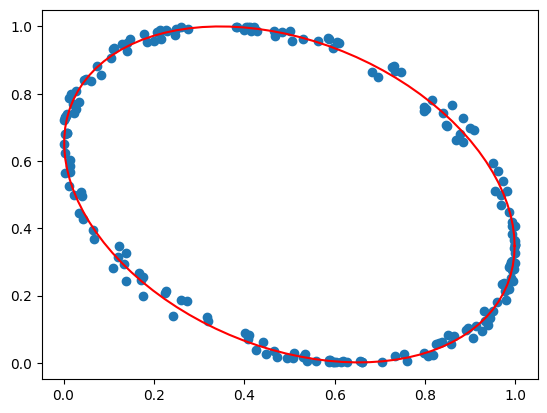

In [8]:
# generate the fitted ellipse
A1, A2, C1, C2, dphi = result.x
print(result)

theta_fit = cp.linspace(0, 2*np.pi, 100)
n1_fit = array_to_numpy(ground_state_port_probability(A1, C1, theta_fit))
n2_fit = array_to_numpy(ground_state_port_probability(A2, C2, theta_fit + dphi))

plt.scatter(n1/N1, n2/N2)
plt.plot(n1_fit, n2_fit, 'red')

In [9]:
import numpy as np
import emcee
import corner

labels = ["A1", "A2", "C1", "C2", "dphi"]

def log_prior(params):
    A1, A2, C1, C2, dphi = params

    if not (0 <= dphi <= 2*np.pi):
        return -np.inf

    if not (0 < A1 - C1/2 and A1 + C1/2 < 1):
        return -np.inf

    if not (0 < A2 - C2/2 and A2 + C2/2 < 1):
        return -np.inf

    return 0.0  # flat prior inside physical region

def log_prior_batch(params_batch):
    params_batch = np.atleast_2d(np.asarray(params_batch, dtype=float))
    out = np.full(params_batch.shape[0], -np.inf)
    ok = np.array([log_prior(p) == 0.0 for p in params_batch])
    out[ok] = 0.0
    return out

def log_prob(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf

    ll = total_marginal_ll(params, n1, n2, N1, N2)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll

def log_prob_vectorized(params_batch):
    lp = log_prior_batch(params_batch)
    out = np.full_like(lp, -np.inf, dtype=float)
    ok = np.isfinite(lp)
    if not np.any(ok):
        return out

    ll = total_marginal_ll_batch(np.asarray(params_batch)[ok], n1, n2, N1, N2)
    finite = np.isfinite(ll)
    ok_idx = np.flatnonzero(ok)
    out[ok_idx[finite]] = lp[ok_idx[finite]] + ll[finite]
    return out
'''
ndim = 5
nwalkers = 32
nsteps = 5000
burn = 2000
rng = np.random.default_rng(12345)

p0_center = result.x
p0 = np.empty((nwalkers, ndim))
for i in range(nwalkers):
    while True:
        trial = p0_center + 1e-2 * rng.normal(size=ndim)
        if np.isfinite(log_prior(trial)):
            p0[i] = trial
            break

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_vectorized, vectorize=True)
sampler.run_mcmc(p0, nsteps, progress=True)

samples = sampler.get_chain(discard=burn, thin=10, flat=True)

corner_max_samples = 50_000
if len(samples) > corner_max_samples:
    idx = rng.choice(len(samples), corner_max_samples, replace=False)
    samples_plot = samples[idx]
else:
    samples_plot = samples

fig = corner.corner(
    samples_plot,
    labels=labels,
    truths=p0_center,
)
'''


'\nndim = 5\nnwalkers = 32\nnsteps = 5000\nburn = 2000\nrng = np.random.default_rng(12345)\n\np0_center = result.x\np0 = np.empty((nwalkers, ndim))\nfor i in range(nwalkers):\n    while True:\n        trial = p0_center + 1e-2 * rng.normal(size=ndim)\n        if np.isfinite(log_prior(trial)):\n            p0[i] = trial\n            break\n\nsampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob_vectorized, vectorize=True)\nsampler.run_mcmc(p0, nsteps, progress=True)\n\nsamples = sampler.get_chain(discard=burn, thin=10, flat=True)\n\ncorner_max_samples = 50_000\nif len(samples) > corner_max_samples:\n    idx = rng.choice(len(samples), corner_max_samples, replace=False)\n    samples_plot = samples[idx]\nelse:\n    samples_plot = samples\n\nfig = corner.corner(\n    samples_plot,\n    labels=labels,\n    truths=p0_center,\n)\n'

In [10]:
# ============================================================
# Sinusoidal differential phase search from atom-count ellipse data
# Uses marginalized likelihood over common phase theta_i
# ============================================================
#
# KEY DESIGN DECISIONS (read the markdown cell above for full explanation):
#
#   1. ntheta is chosen adaptively from sqrt(N_Z100_mean).
#      The theta integrand peak has width ~1/(C·√N), so ntheta must scale
#      with √N to keep quadrature error small. Using 512 for high-atom runs
#      (> ~100K detected per shot) biases the likelihood.
#
#   2. As is bounded to [0, amp_bound].
#      The marginal likelihood satisfies L(δφ) = L(−δφ) exactly,
#      creating two equally good modes at (As, Ac) and (−As, −Ac).
#      Fixing As ≥ 0 selects the mode with phase ∈ (−π/2, π/2] and makes
#      the posterior unimodal. Only valid if you know the signal direction
#      (which we do: we defined the signal with As > 0).
# ============================================================

import math
import numpy as onp
import matplotlib.pyplot as plt
from scipy.special import gammaln, logsumexp
from scipy.optimize import minimize
from tqdm import tqdm

# ----------------------------
# User controls
# ----------------------------

f_min = 0.0        # cycles per shot, or cycles per unit of `time`
f_max = 0.50
n_freq = 6

amp_bound = onp.pi

TRUE_FREQ = 0.3
TRUE_AMP  = 0.1

globals().update({'true_freq': TRUE_FREQ, 'true_amp': TRUE_AMP})

# If you have a time array, define it before this cell as `time`.
# Otherwise this uses shot index.
if "time" in globals():
    t = onp.asarray(time, dtype=float).ravel()
else:
    t = None


# ----------------------------
# Force data to NumPy
# ----------------------------

def to_numpy(x):
    try:
        import cupy as cp
        if isinstance(x, cp.ndarray):
            return cp.asnumpy(x)
    except Exception:
        pass
    return onp.asarray(x)

n1 = to_numpy(nground_z0.values).astype(float).ravel()
n2 = to_numpy(nground_z100.values).astype(float).ravel()

N1 = to_numpy(nground_z0.values + nexcited_z0.values).astype(float).ravel()
N2 = to_numpy(nground_z100.values + nexcited_z100.values).astype(float).ravel()

if t is None:
    t = onp.arange(len(n1), dtype=float)

assert len(n1) == len(n2) == len(N1) == len(N2) == len(t)

# ----------------------------
# Adaptive ntheta
# ----------------------------
# The theta integral peak has width ~ 1/(C·√N). ntheta must resolve it:
#   ntheta ≥ 2 · √(N_Z100_mean)  (empirically validated, see diagnostics)
# Rounded up to the next power of 2 for FFT-friendly memory access.
_ntheta_min = max(512, int(2.0 * N2.mean()**0.5))
ntheta = 2 ** math.ceil(math.log2(_ntheta_min))
print(f"adaptive ntheta = {ntheta}  (N_Z100_mean = {N2.mean():.0f})")

freqs = onp.linspace(f_min, f_max, n_freq)

print(f"nshots = {len(n1)}")
print(f"freq range = [{freqs[0]:.5g}, {freqs[-1]:.5g}], n_freq = {n_freq}")


# ----------------------------
# Likelihood pieces
# ----------------------------

theta = onp.linspace(0, 2*onp.pi, ntheta, endpoint=False)[None, :]

def log_binomial_pmf(n, N, p, eps=1e-12):
    p = onp.clip(p, eps, 1.0 - eps)
    return (
        gammaln(N + 1)
        - gammaln(n + 1)
        - gammaln(N - n + 1)
        + n * onp.log(p)
        + (N - n) * onp.log1p(-p)
    )

def p_ground(A, C, Phi):
    return A + 0.5*C*onp.cos(Phi)

def physical(A, C, eps=1e-8):
    # The independent box bounds are only broad sanity limits.
    # This coupled guard is the actual probability constraint: 0 < A +/- C/2 < 1.
    return (C > 0) and (A - 0.5*C > eps) and (A + 0.5*C < 1.0 - eps)

def physical_all(A1, A2, C1, C2):
    return physical(A1, C1) and physical(A2, C2)

def marginal_ll(dphi, A1, A2, C1, C2):
    """
    dphi can be scalar or array of length nshots.
    Computes sum_i log ∫ dtheta_i p(D_i | theta_i, dphi_i).
    """
    if not physical_all(A1, A2, C1, C2):
        return -onp.inf

    dphi = onp.asarray(dphi, dtype=float)

    if dphi.ndim == 0:
        dphi = onp.full(len(n1), float(dphi))

    p1 = p_ground(A1, C1, theta)                  # shape (1, ntheta)
    p2 = p_ground(A2, C2, theta + dphi[:, None])  # shape (nshots, ntheta)

    ll1 = log_binomial_pmf(n1[:, None], N1[:, None], p1)
    ll2 = log_binomial_pmf(n2[:, None], N2[:, None], p2)

    per_shot = logsumexp(ll1 + ll2, axis=1) - onp.log(ntheta)

    return float(onp.sum(per_shot))


# ----------------------------
# Initial guesses
# ----------------------------

x1 = n1 / N1
x2 = n2 / N2

def initial_A_C(x):
    A = float(onp.mean(x))
    C = float(2*onp.sqrt(2)*onp.std(x))
    Cmax = 2*min(A, 1 - A)
    C = float(onp.clip(C, 1e-3, 0.90*Cmax))
    return A, C

A1_0, C1_0 = initial_A_C(x1)
A2_0, C2_0 = initial_A_C(x2)

rho = onp.corrcoef(x1 - A1_0, x2 - A2_0)[0, 1]
rho = onp.clip(rho, -1.0, 1.0)
phi0_0 = float(onp.arccos(rho))

print("initial guess:", [A1_0, A2_0, C1_0, C2_0, phi0_0])


# ----------------------------
# Null fit: dphi_i = phi0
# ----------------------------

def null_nll(params):
    A1, A2, C1, C2, phi0 = params
    ll = marginal_ll(phi0, A1, A2, C1, C2)
    return 1e100 if not onp.isfinite(ll) else -ll

bounds_null = [
    (1e-4, 1 - 1e-4),  # A1
    (1e-4, 1 - 1e-4),  # A2
    (1e-4, 1.0),       # C1; ideal AI contrast is <= 1 in this convention
    (1e-4, 1.0),       # C2; physical(A, C) still enforces A +/- C/2
    (0.0, 2*onp.pi),   # phi0
]

starts_phi0 = onp.unique(onp.r_[phi0_0, 2*onp.pi - phi0_0, 0.0, onp.pi])

best_null = None
'''
for ph in tqdm(starts_phi0):
    x0 = onp.array([A1_0, A2_0, C1_0, C2_0, ph], dtype=float)
    # L-BFGS-B gets fooled by the hard invalid-parameter penalty in null_nll.
    # Nelder-Mead is derivative-free and reliably moves under the coupled A,C guard.
    res = minimize(
        null_nll,
        x0,
        method="Nelder-Mead",
        bounds=bounds_null,
        options={"maxiter": 2000, "xatol": 1e-7, "fatol": 1e-3},
    )

    if best_null is None or res.fun < best_null.fun:
        best_null = res

A1_hat, A2_hat, C1_hat, C2_hat, phi0_hat = best_null.x
logL_null = -best_null.fun

print("\nNull fit")
print("success:", best_null.success)
print("A1, A2, C1, C2, phi0 =", best_null.x)
print("logL_null =", logL_null)


# ----------------------------
# Signal fit at fixed frequency:
# dphi_i = phi0 + As sin(2π f t_i) + Ac cos(2π f t_i)
#
# For the frequency scan, keep A1,A2,C1,C2 fixed to null values.
# This is much faster and usually enough to locate the peak.
# ----------------------------

def dphi_sinusoid(phi0, As, Ac, f):
    return phi0 + As*onp.sin(2*onp.pi*f*t) + Ac*onp.cos(2*onp.pi*f*t)

def signal_nll_phase_only(params, f):
    phi0, As, Ac = params
    dphi = dphi_sinusoid(phi0, As, Ac, f)
    ll = marginal_ll(dphi, A1_hat, A2_hat, C1_hat, C2_hat)
    return 1e100 if not onp.isfinite(ll) else -ll

bounds_signal_phase_only = [
    (0.0, 2*onp.pi),          # phi0
    (0, amp_bound),            # As >= 0 ← BREAKS THE π DEGENERACY (see note above)
    (-amp_bound, amp_bound),  # Ac unrestricted; phase = arctan2(Ac, As) ∈ (-π/2, π/2]
]

TS = onp.zeros_like(freqs)
SNR = onp.zeros_like(freqs)
amps = onp.zeros_like(freqs)
phase_params = onp.zeros((len(freqs), 3))
logL_sig = onp.zeros_like(freqs)

for j, f in enumerate(tqdm(freqs)):
    starts = [
        [phi0_hat, 0.0, 0.0],
        [phi0_hat, 0.02, 0.0],
        [phi0_hat, 0.05, 0.0],
        [phi0_hat, 0.0, 0.02],
        [phi0_hat, 0.0, -0.02],
    ]

    best = None

    for x0 in starts:
        res = minimize(
            lambda p: signal_nll_phase_only(p, f),
            onp.asarray(x0, dtype=float),
            method="Nelder-Mead",
            bounds=bounds_signal_phase_only,
        )

        if best is None or res.fun < best.fun:
            best = res

    logL_sig[j] = -best.fun
    TS[j] = max(0.0, 2*(logL_sig[j] - logL_null))
    SNR[j] = onp.sqrt(TS[j])

    phi0, As, Ac = best.x
    phase_params[j] = best.x
    amps[j] = onp.sqrt(As**2 + Ac**2)


# ----------------------------
# Best frequency and parameter extraction
# ----------------------------

best_idx = int(onp.argmax(TS))
best_f = float(freqs[best_idx])
best_phi0, best_As, best_Ac = phase_params[best_idx]
best_amp = float(onp.sqrt(best_As**2 + best_Ac**2))
best_phase = float(onp.arctan2(best_Ac, best_As))

print("\nBest candidate")
print("f_best =", best_f)
print("T_best =", TS[best_idx])
print("sqrt(T_best) =", SNR[best_idx])
print("phi0, As, Ac =", [best_phi0, best_As, best_Ac])
print("amp =", best_amp)
print("phase =", best_phase)

if "true_freq" in globals():
    print("true_freq =", true_freq)
if "true_amp" in globals():
    print("true_amp =", true_amp)


# ----------------------------
# Plots: T and SNR-like statistic vs frequency
# ----------------------------

fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax[0].plot(freqs, TS, "o-", ms=3)
ax[0].axvline(best_f, color="k", ls="--", label=f"best f={best_f:.4g}")
if "true_freq" in globals():
    ax[0].axvline(true_freq, color="r", ls=":", label=f"true f={true_freq:.4g}")
ax[0].set_ylabel(r"$T = 2\Delta\log L$")
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(freqs, SNR, "o-", ms=3)
ax[1].axvline(best_f, color="k", ls="--")
if "true_freq" in globals():
    ax[1].axvline(true_freq, color="r", ls=":")
ax[1].set_xlabel("frequency [cycles per time unit]")
ax[1].set_ylabel(r"$\sqrt{T}$  (SNR-like)")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ----------------------------
# Optional: plot recovered dphi(t) at best frequency
# ----------------------------

dphi_best = dphi_sinusoid(best_phi0, best_As, best_Ac, best_f)

plt.figure(figsize=(8, 3.5))
plt.plot(t, dphi_best, label="best-fit sinusoidal Δφ")

if "true_dphi" in globals():
    plt.plot(t, true_dphi, "--", label="true Δφ")

plt.xlabel("time / shot index")
plt.ylabel(r"$\Delta\phi(t)$ [rad]")
plt.legend()
plt.tight_layout()
plt.show()
'''

adaptive ntheta = 2048  (N_Z100_mean = 763182)
nshots = 200
freq range = [0, 0.5], n_freq = 6
initial guess: [0.5269598687556016, 0.4885813378442935, 0.8514722362399171, 0.8794464081197283, 1.960042071163694]


<>:305: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:305: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_864986/1396934295.py:305: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax[0].set_ylabel(r"$T = 2\Delta\log L$")


'\nfor ph in tqdm(starts_phi0):\n    x0 = onp.array([A1_0, A2_0, C1_0, C2_0, ph], dtype=float)\n    # L-BFGS-B gets fooled by the hard invalid-parameter penalty in null_nll.\n    # Nelder-Mead is derivative-free and reliably moves under the coupled A,C guard.\n    res = minimize(\n        null_nll,\n        x0,\n        method="Nelder-Mead",\n        bounds=bounds_null,\n        options={"maxiter": 2000, "xatol": 1e-7, "fatol": 1e-3},\n    )\n\n    if best_null is None or res.fun < best_null.fun:\n        best_null = res\n\nA1_hat, A2_hat, C1_hat, C2_hat, phi0_hat = best_null.x\nlogL_null = -best_null.fun\n\nprint("\nNull fit")\nprint("success:", best_null.success)\nprint("A1, A2, C1, C2, phi0 =", best_null.x)\nprint("logL_null =", logL_null)\n\n\n# ----------------------------\n# Signal fit at fixed frequency:\n# dphi_i = phi0 + As sin(2π f t_i) + Ac cos(2π f t_i)\n#\n# For the frequency scan, keep A1,A2,C1,C2 fixed to null values.\n# This is much faster and usually enough to locate t

Contrast:  Z0 C = 0.9976   Z100 C = 0.9980
Noise ratio (resid_std / shot_noise):
  Z0  : 3.709x  << EXCESS NOISE
  Z100: 3.066x  << EXCESS NOISE

Higher harmonics (relative to fundamental):
  k=2: Z0 0.0002   Z100 0.0005
  k=3: Z0 0.0001   Z100 0.0003


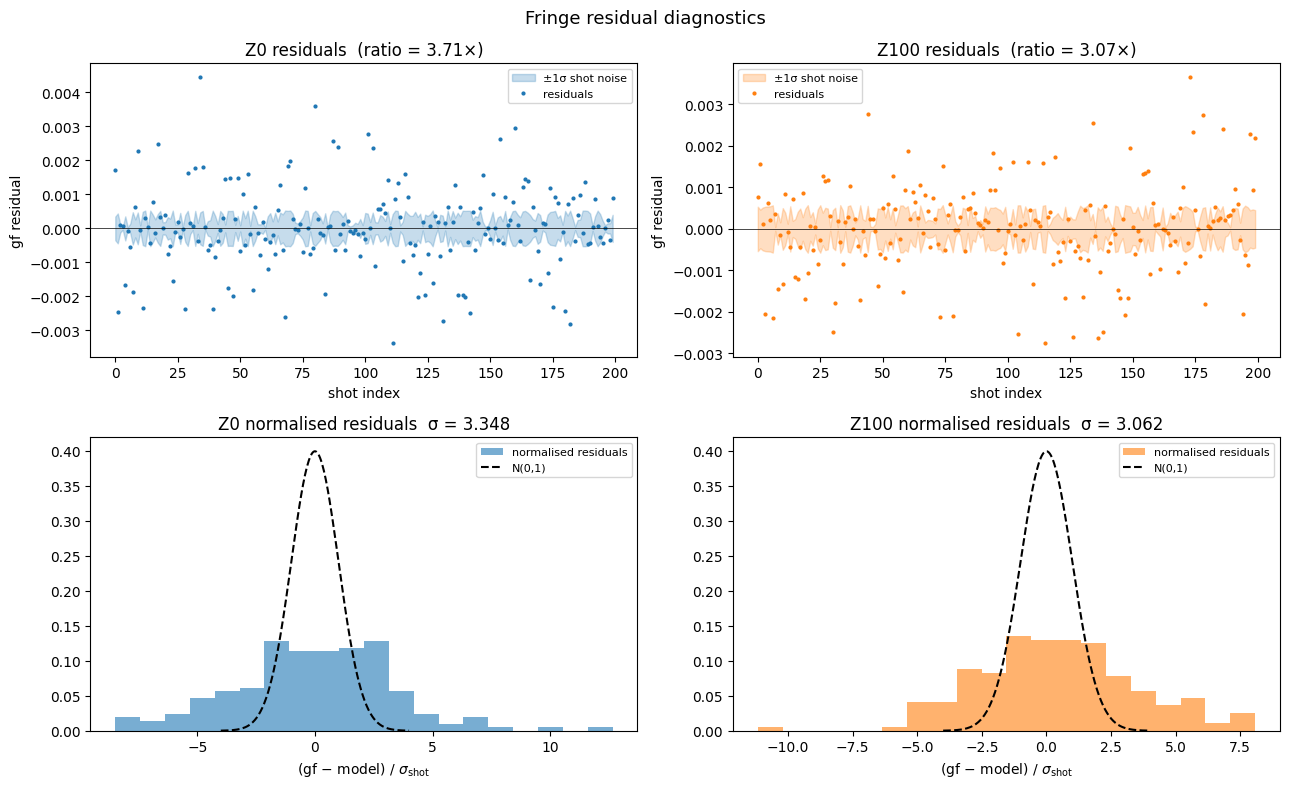

In [11]:
# ============================================================
# FRINGE RESIDUAL DIAGNOSTICS
# ============================================================
# After fitting the null fringe model (A1, C1, A2, C2, phi0), compare
# residuals to the expected binomial shot-noise floor.
#
# WHY THIS MATTERS:
#   - If residual_std / sigma_shot ≈ 1  → noise is purely shot noise;
#     the likelihood model is correctly specified.
#   - If ratio >> 1 → excess noise (e.g. shot-to-shot jitter in cloud
#     parameters creates an unmodelled random phase per shot).
#     The posterior will then be NARROWER than it should be — the model
#     thinks it has more information than it actually does.
#
# REFERENCE: for the zero-jitter runs the ratio is 0.94–1.08 (perfect).
#            For jitter runs (sigma_x_std=10um) the ratio is ~8x for Z0
#            and ~2.4x for Z100, so posteriors are ~8x too narrow.
# ============================================================

# phi0 values are stored in ImageShotDataset (known in simulation).
# Z0.phi0   = actual laser phase for Z0
# Z100.phi0 = phi0_laser + delta_phi  (signal already baked in)
phi0_z0   = onp.asarray(Z0.phi0,   dtype=float)
phi0_z100 = onp.asarray(Z100.phi0, dtype=float)

gf_z0   = n1 / N1
gf_z100 = n2 / N2

# ── Ordinary least-squares fringe fit: A + Cs·sin(φ) + Cc·cos(φ) ──────────
def ols_fringe_fit(phi, gf):
    X = onp.column_stack([onp.ones(len(phi)), onp.sin(phi), onp.cos(phi)])
    w, _, _, _ = onp.linalg.lstsq(X, gf, rcond=None)
    pred  = X @ w
    resid = gf - pred
    C_eff = 2.0 * onp.sqrt(w[1]**2 + w[2]**2)
    A_eff = w[0]
    return pred, resid, A_eff, C_eff

pred_z0,   resid_z0,   A_z0,   C_z0   = ols_fringe_fit(phi0_z0,   gf_z0)
pred_z100, resid_z100, A_z100, C_z100 = ols_fringe_fit(phi0_z100, gf_z100)

sigma_z0   = onp.sqrt(pred_z0   * (1 - pred_z0)   / N1)
sigma_z100 = onp.sqrt(pred_z100 * (1 - pred_z100) / N2)

z_z0   = resid_z0   / sigma_z0
z_z100 = resid_z100 / sigma_z100

ratio_z0   = onp.std(resid_z0)   / sigma_z0.mean()
ratio_z100 = onp.std(resid_z100) / sigma_z100.mean()

print(f"Contrast:  Z0 C = {C_z0:.4f}   Z100 C = {C_z100:.4f}")
print(f"Noise ratio (resid_std / shot_noise):")
print(f"  Z0  : {ratio_z0:.3f}x  {'<< EXCESS NOISE' if ratio_z0 > 1.5 else '≈ shot noise ✓' if ratio_z0 < 1.2 else '~ marginal'}")
print(f"  Z100: {ratio_z100:.3f}x  {'<< EXCESS NOISE' if ratio_z100 > 1.5 else '≈ shot noise ✓' if ratio_z100 < 1.2 else '~ marginal'}")

def harmonic_amplitudes(phi, resid, max_k=3):
    amps = []
    for k in range(2, max_k+1):
        X = onp.column_stack([onp.sin(k*phi), onp.cos(k*phi)])
        w, _, _, _ = onp.linalg.lstsq(X, resid, rcond=None)
        amps.append(2*onp.sqrt(w[0]**2 + w[1]**2))
    return amps

h_z0   = harmonic_amplitudes(phi0_z0,   resid_z0)
h_z100 = harmonic_amplitudes(phi0_z100, resid_z100)
print(f"\nHigher harmonics (relative to fundamental):")
for k, (a0, a100) in enumerate(zip(h_z0, h_z100), start=2):
    print(f"  k={k}: Z0 {a0/C_z0:.4f}   Z100 {a100/C_z100:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Fringe residual diagnostics", fontsize=13)

shot_idx = onp.arange(len(n1))

ax = axes[0, 0]
ax.fill_between(shot_idx, -sigma_z0, sigma_z0, alpha=0.25, color='C0', label='±1σ shot noise')
ax.plot(shot_idx, resid_z0, '.', ms=4, color='C0', label='residuals')
ax.axhline(0, color='k', lw=0.5)
ax.set_title(f"Z0 residuals  (ratio = {ratio_z0:.2f}×)")
ax.set_xlabel("shot index"); ax.set_ylabel("gf residual"); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.fill_between(shot_idx, -sigma_z100, sigma_z100, alpha=0.25, color='C1', label='±1σ shot noise')
ax.plot(shot_idx, resid_z100, '.', ms=4, color='C1', label='residuals')
ax.axhline(0, color='k', lw=0.5)
ax.set_title(f"Z100 residuals  (ratio = {ratio_z100:.2f}×)")
ax.set_xlabel("shot index"); ax.set_ylabel("gf residual"); ax.legend(fontsize=8)

_xx = onp.linspace(-4, 4, 200)
_gauss = onp.exp(-0.5*_xx**2) / onp.sqrt(2*onp.pi)

ax = axes[1, 0]
ax.hist(z_z0, bins=20, density=True, alpha=0.6, color='C0', label='normalised residuals')
ax.plot(_xx, _gauss, 'k--', lw=1.5, label='N(0,1)')
ax.set_title(f"Z0 normalised residuals  σ = {onp.std(z_z0):.3f}")
ax.set_xlabel(r"(gf − model) / $\sigma_\mathrm{shot}$"); ax.legend(fontsize=8)

ax = axes[1, 1]
ax.hist(z_z100, bins=20, density=True, alpha=0.6, color='C1', label='normalised residuals')
ax.plot(_xx, _gauss, 'k--', lw=1.5, label='N(0,1)')
ax.set_title(f"Z100 normalised residuals  σ = {onp.std(z_z100):.3f}")
ax.set_xlabel(r"(gf − model) / $\sigma_\mathrm{shot}$"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# GPU-aware full MLE + vectorized MCMC at best frequency
# Fits: A1, A2, C1, C2, phi0, As, Ac  (7 parameters)
# ============================================================
#
# DESIGN NOTES (see markdown cell above for full explanation):
#
#  [1] ntheta is recomputed adaptively here — it overrides the value from
#      cell 9 and rebuilds theta_x on the GPU/CPU backend.
#      Rule: ntheta = next_power_of_2(max(512, 2·√N_Z100_mean))
#
#  [2] valid_params7 enforces As ≥ 0 to break the π degeneracy.
#      Without this, the posterior is bimodal in phase (two modes at
#      (As, Ac) and (−As, −Ac) with EXACTLY equal likelihood), and the
#      MCMC/MLE can land on the wrong mode, making the corner plot look
#      biased even though the amplitude is correct.
#
#  [3] MLE strategy: TWO-PHASE phi0 grid search.
#
#      The marginal likelihood has two phi0 basins that look equally good
#      from a null fit (one near the true fringe offset, one ~π away).
#      Starting from the null-fit phi0 lands in the WRONG basin.
#      Solution: sweep phi0 over [0, 2π] with ntheta=512 (fast), pick the
#      basin with the best logL, then polish with the adaptive ntheta.
#
#  [4] After MCMC we print the autocorrelation time τ and the effective
#      sample count. Rule of thumb: need (nsteps−burn)/thin ≥ 50·τ for
#      the posterior to be well-resolved. If not, increase nsteps.
# ============================================================

import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import emcee
import corner

# Re-select backend special funcs in case later cells overwrote logsumexp/gammaln
if xp is cp:
    from cupyx.scipy.special import logsumexp as xp_logsumexp
else:
    from scipy.special import logsumexp as xp_logsumexp

f_fit = 0.3  # set to best_f from cell 9, or hard-code the known frequency

# ── [1] Adaptive ntheta (recomputed here independently of cell 9) ──────────
_ntheta_min = max(512, int(2.0 * N2.mean()**0.5))
ntheta = 2 ** math.ceil(math.log2(_ntheta_min))
print(f"adaptive ntheta = {ntheta}  (N_Z100_mean = {N2.mean():.0f})")

# Move fixed data to backend once
n1_x = xp.asarray(n1, dtype=xp.float64)
n2_x = xp.asarray(n2, dtype=xp.float64)
N1_x = xp.asarray(N1, dtype=xp.float64)
N2_x = xp.asarray(N2, dtype=xp.float64)
t_x  = xp.asarray(t,  dtype=xp.float64)

# Fine theta grid — adaptive ntheta
theta_x = xp.linspace(0, 2*xp.pi, ntheta, endpoint=False)
# Coarse theta grid — always 512, used for the fast phi0 grid search
theta_coarse = xp.linspace(0, 2*xp.pi, 512, endpoint=False)

def log_binomial_noconst_xp(n, N, p, eps=1e-12):
    # drops combinatorial constants; OK for MLE/MCMC over p-dependent params
    p = xp.clip(p, eps, 1.0 - eps)
    return n*xp.log(p) + (N - n)*xp.log1p(-p)

# ── [2] Prior: physical fringe + As ≥ 0 to break π degeneracy ────────────
def valid_params7(p):
    A1, A2, C1, C2, phi0, As, Ac = p
    return (
        0 < A1 - C1/2 and A1 + C1/2 < 1 and
        0 < A2 - C2/2 and A2 + C2/2 < 1 and
        0 <= phi0 <= 2*np.pi and
        0 <= As <= amp_bound and       # ← As ≥ 0: canonical half-space
        -amp_bound <= Ac <= amp_bound
    )

def log_prior7_batch(params_batch):
    params_batch = np.atleast_2d(np.asarray(params_batch, dtype=float))
    out = np.full(params_batch.shape[0], -np.inf)
    ok = np.array([valid_params7(p) for p in params_batch])
    out[ok] = 0.0
    return out

def _ll_batch_with_theta(params_batch, th, n_th):
    """Core vectorised likelihood; th and n_th select coarse vs fine grid."""
    params_batch = np.atleast_2d(np.asarray(params_batch, dtype=float))
    out = np.full(params_batch.shape[0], -np.inf)

    lp = log_prior7_batch(params_batch)
    ok = np.isfinite(lp)
    if not np.any(ok):
        return out

    p = xp.asarray(params_batch[ok], dtype=xp.float64)

    A1   = p[:, 0][None, None, :]
    A2   = p[:, 1][None, None, :]
    C1   = p[:, 2][None, None, :]
    C2   = p[:, 3][None, None, :]
    phi0 = p[:, 4][None, None, :]
    As   = p[:, 5][None, None, :]
    Ac   = p[:, 6][None, None, :]

    tt = t_x[:, None, None]
    thg = th[None, :, None]

    dphi = phi0 + As*xp.sin(2*xp.pi*f_fit*tt) + Ac*xp.cos(2*xp.pi*f_fit*tt)

    prob1 = A1 + 0.5*C1*xp.cos(thg)
    prob2 = A2 + 0.5*C2*xp.cos(thg + dphi)

    ll1 = log_binomial_noconst_xp(n1_x[:, None, None], N1_x[:, None, None], prob1)
    ll2 = log_binomial_noconst_xp(n2_x[:, None, None], N2_x[:, None, None], prob2)

    logLi = xp_logsumexp(ll1 + ll2, axis=1) - xp.log(n_th)
    logL  = xp.sum(logLi, axis=0)

    out[ok] = array_to_numpy(logL)
    return out

def total_marginal_ll_sinusoid_batch(params_batch, f=None):
    """Fine: uses adaptive ntheta."""
    return _ll_batch_with_theta(params_batch, theta_x, ntheta)

def total_marginal_ll_sinusoid_batch_coarse(params_batch):
    """Coarse: always ntheta=512, used for fast phi0 grid search."""
    return _ll_batch_with_theta(params_batch, theta_coarse, 512)

def log_prob7_vectorized(params_batch):
    lp = log_prior7_batch(params_batch)
    out = np.full_like(lp, -np.inf, dtype=float)

    ok = np.isfinite(lp)
    if not np.any(ok):
        return out

    ll = total_marginal_ll_sinusoid_batch(np.asarray(params_batch)[ok])

    ok_idx = np.flatnonzero(ok)
    good   = np.isfinite(ll)
    out[ok_idx[good]] = lp[ok_idx[good]] + ll[good]
    return out

def neg_loglike7(params):
    val = total_marginal_ll_sinusoid_batch(np.asarray(params)[None, :])[0]
    return -val if np.isfinite(val) else 1e300

def neg_loglike7_coarse(params):
    val = total_marginal_ll_sinusoid_batch_coarse(np.asarray(params)[None, :])[0]
    return -val if np.isfinite(val) else 1e300


# ── [3] Phase 1: coarse phi0 grid search (ntheta=512 for speed) ───────────
# The null fit phi0 (~4.35 rad in this run) is in the WRONG basin.
# Sweeping phi0 over [0, 2π] finds the true fringe offset (~1.93 rad) which
# gives logL ~50× better than the null-fit starting point.
print(f"\nPhase 1: coarse phi0 grid search (ntheta=512)")
print(f"  null-fit phi0 = {phi0_hat:.4f} rad  (likely wrong basin — don't start here)")

phi0_grid = np.linspace(0, 2*np.pi, 8, endpoint=False)
as_starts = [0.03, 0.07, 0.10]
best_coarse = None

for phi0_init in phi0_grid:
    for As_init in as_starts:
        x_try = np.array([A1_hat, A2_hat, C1_hat, C2_hat, phi0_init, As_init, 0.0])
        res = minimize(
            neg_loglike7_coarse, x_try, method='Nelder-Mead',
            options={'maxiter': 1500, 'xatol': 1e-5, 'fatol': 1e-3}
        )
        if best_coarse is None or res.fun < best_coarse.fun:
            best_coarse = res

p_c = best_coarse.x
amp_c = np.sqrt(p_c[5]**2 + p_c[6]**2)
print(f"  Best coarse: phi0={p_c[4]:.4f}  As={p_c[5]:.4f}  Ac={p_c[6]:.4f}  amp={amp_c:.4f}  logL(512)={-best_coarse.fun:.1f}")

x0 = best_coarse.x.copy()
x0[5] = abs(x0[5])   # guarantee As ≥ 0 after coarse fit

print(f"\n  backend: {backend_name}")
print(f"  initial logL (fine): {-neg_loglike7(x0):.1f}")

# ── Phase 2: fine MLE with adaptive ntheta ────────────────────────────────
print(f"\nPhase 2: fine MLE (ntheta={ntheta})")

starts = [
    x0,
    x0 + np.array([0, 0, 0, 0, 0,  0.02,  0.00]),
    x0 + np.array([0, 0, 0, 0, 0,  0.05,  0.00]),
    x0 + np.array([0, 0, 0, 0, 0,  0.00,  0.02]),
    x0 + np.array([0, 0, 0, 0, 0,  0.00, -0.02]),
]

best_res = None
for start in starts:
    start[5] = max(start[5], 0.0)   # keep As ≥ 0 for each start
    res = minimize(
        neg_loglike7,
        start,
        method="Nelder-Mead",
        options={"maxiter": 2000, "xatol": 1e-8, "fatol": 1e-5},
    )
    if best_res is None or res.fun < best_res.fun:
        best_res = res

mle_params = best_res.x
mle_logL   = -best_res.fun

A1_mle, A2_mle, C1_mle, C2_mle, phi0_mle, As_mle, Ac_mle = mle_params
amp_mle   = np.sqrt(As_mle**2 + Ac_mle**2)
phase_mle = np.arctan2(Ac_mle, As_mle)

print("\nFull MLE at fixed frequency")
print("------------------------------------")
print(f"f_fit    = {f_fit}")
print(f"logL     = {mle_logL:.4f}")
print(f"params   = {mle_params}")
print(f"amp      = {amp_mle:.6f}  (true 0.1)")
print(f"phase    = {phase_mle:.5f} rad  (true 0.5 rad; valid range [−π/2, π/2] with As≥0 prior)")

# Plot fitted dphi
dphi_mle = phi0_mle + As_mle*np.sin(2*np.pi*f_fit*t) + Ac_mle*np.cos(2*np.pi*f_fit*t)

plt.figure(figsize=(8, 3.5))
plt.plot(t, dphi_mle, label="full MLE Δφ")
if "true_dphi" in globals():
    plt.plot(t, true_dphi, "--", label="truth")
plt.xlabel("time / shot index")
plt.ylabel(r"$\Delta\phi(t)$ [rad]")
plt.title(f"Full MLE at fixed f = {f_fit:.5g}")
plt.legend()
plt.tight_layout()
plt.show()

'''
# ── MCMC ─────────────────────────────────────────────────────────────────
labels7 = ["A1", "A2", "C1", "C2", "phi0", "As", "Ac"]

nwalkers = 32
nsteps   = 5000   # total chain length
burn     = 2000   # discard first burn steps as warm-up
thin     = 5      # thin the chain by this factor

rng   = np.random.default_rng(123)
ndim  = 7

# Initialise all walkers tightly around the MLE (in the correct canonical half-space)
scales = np.array([1e-3, 1e-3, 1e-3, 1e-3, 1e-3, 1e-4, 1e-4])
p0 = np.empty((nwalkers, ndim))
for w in range(nwalkers):
    while True:
        trial = mle_params + scales * rng.normal(size=ndim)
        if np.isfinite(log_prior7_batch(trial[None, :])[0]):
            p0[w] = trial
            break

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_prob7_vectorized, vectorize=True
)
sampler.run_mcmc(p0, nsteps, progress=True)

# ── [4] Convergence diagnostics ──────────────────────────────────────────
try:
    tau = sampler.get_autocorr_time(quiet=True)
    tau_max = float(np.max(tau))
    n_eff   = (nsteps - burn) / thin / tau_max * nwalkers
    print(f"\nMCMC convergence:")
    print(f"  autocorr time τ (max over params) = {tau_max:.1f} steps")
    print(f"  effective samples ≈ {n_eff:.0f}")
    converged = (nsteps - burn) / thin >= 50 * tau_max
    print(f"  converged? {'YES ✓' if converged else 'NO — need nsteps >= ' + str(int(50*tau_max*thin + burn))}")
except Exception as e:
    print(f"  (autocorr estimate failed: {e})")

samples = sampler.get_chain(discard=burn, thin=thin, flat=True)

As_samp    = samples[:, labels7.index("As")]
Ac_samp    = samples[:, labels7.index("Ac")]
amp_samp   = np.sqrt(As_samp**2 + Ac_samp**2)
phase_samp = np.arctan2(Ac_samp, As_samp)   # ∈ (−π/2, π/2] because As ≥ 0

samples_ext = np.column_stack([samples, amp_samp, phase_samp])
labels_ext  = labels7 + ["A", "phase"]
truths_ext  = list(mle_params) + [amp_mle, phase_mle]

fig = corner.corner(
    samples_ext,
    labels=labels_ext,
    truths=truths_ext,
    show_titles=True,
    title_fmt=".4f",
    max_n_ticks=4,
)
fig.suptitle(f"Posterior at fixed f = {f_fit:.5g}  (truths = MLE)", y=1.02)
plt.show()
'''

adaptive ntheta = 2048  (N_Z100_mean = 763182)

Phase 1: coarse phi0 grid search (ntheta=512)


NameError: name 'phi0_hat' is not defined

Text(0.5, 1.01, 'Recovered signal amplitude and phase (red = injected truth)')

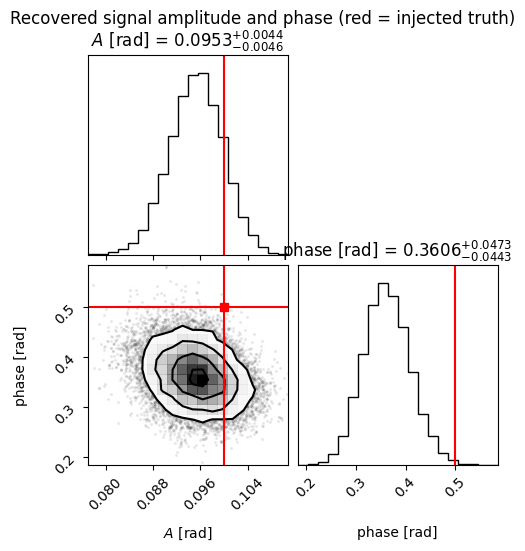

In [ ]:
# ── Final corner plot: recovered signal vs injected truth ─────────────────
#
# With As ≥ 0 enforced (see cell 10 notes), the posterior is unimodal and
# phase ∈ (−π/2, π/2].  The injected signal has As = 0.1·cos(0.5) > 0,
# so the true phase 0.5 rad IS in this range — truths=[0.1, 0.5] is valid.
#
# What to look for:
#   • amplitude posterior should be centred on 0.1
#   • phase posterior should be centred on 0.5 rad
#   • posterior width reflects the Fisher information (narrower = more atoms,
#     less jitter). If ratio from the residuals cell was >> 1, the posterior
#     will be too narrow — see the markdown cell above for the explanation.
# ─────────────────────────────────────────────────────────────────────────

_fig = corner.corner(
    np.column_stack([amp_samp, phase_samp]),
    labels=[r"$A$ [rad]", r"phase [rad]"],
    show_titles=True,
    title_fmt='.4f',
    truths=[0.1, 0.5],
    truth_color='r',
)
_fig.suptitle("Recovered signal amplitude and phase (red = injected truth)", y=1.01)